In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

import numpy untuk mengolah data atau nilai piksel yg berbentuk array atau matriks.

import cv2 digunakan untuk mengimport library OpenCV. penggunaan library dalam kode ini digunakan untuk mengubah warna menjadi abu atau grayscale.

import matplotlib.pyplot as plt digunakan untuk memanggil modul pyplot dari library Matplotlib dengan alias plt. Modul ini berfungsi untuk menampilkan visualisasi, seperti gambar dan grafik.

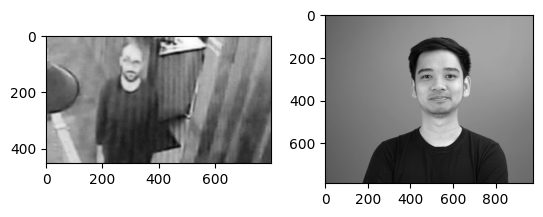

In [2]:
backup = cv2.cvtColor(cv2.imread('backup.jpg'), cv2.COLOR_BGR2GRAY)
david = cv2.cvtColor(cv2.imread('david.jpg'), cv2.COLOR_BGR2GRAY)

plt.subplot(2,2,1)
plt.imshow(backup, cmap='gray')
plt.subplot(2,2,2)
plt.imshow(david, cmap='gray')

plt.show()

citra backup.jpg dan david.jpg terlebih dulu dibaca dengan cv2.imread(), kemudian dikonversi menjadi citra grayscale dengan cv2.cvtColor(..., cv2.COLOR_BGR2GRAY). proses grayscale dilakukan untuk menyederhanakan informasi citra dari tiga kanal warna (RGB/BGR) menjadi satu kanal intensitas abu-abu sehingga pemrosesan citra menjadi lebih mudah. setelah itu, kedua citra ditampilkan dengan menggunakan matplotlip dengan colormap gray agar perbedaan intensitas objek dan latar belakang dapat terlihat ebih jelas.

In [3]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size*size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total = 0
                    for val in region.ravel():
                        total+=int(val)
                    canvas[i, j] = total / area

        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = np.sort(region.ravel())
                    canvas[i, j] = values[len(values) // 2]
        
        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i,j] = mode_val
    return canvas

#cara panggil
#hasil = filter(foto_bla, 3, 'mean')

fungsi filter() digunakan untuk melakukan proses filtering pada citra grayscale menggunakan tiga metode berbeda, yaitu mean, median, dan modus. citra terlebih dahulu diberi padding menggunakan np.pad() agar proses filter tetap dapat dilakukan pada bagian tepi gambar. pada mode mean, nilai piksel baru diperoleh dari rata-rata seluruh piksel di dalam kernel sehingga citra menjadi lebih haus, namun detail tepi dapat sedikir kabur. pada mode median, nilai piksel ditentukan dari nilai tengah setelah data diurutkan, sehingga efektif untuk mengurangi noise salt & pepper tanpa terlalu merusak tepi objek. sementara itu, mode modus memilih nilai piksel yang paling sering muncul dalam area kernelm sehingga dapat mempertahankan pola dominan pada citra. hasil filtering kemudian disimpan pada variabel canvas dan dikembalikan sebagai citra baru yg telah diproses.

In [4]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img,pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i,j] = np.sum(region * kernel)
    return canvas

#cara panggil
#hasil = convolution(fotoMarsha, kernel)

fungsi convolution() digunakan untuk menerapkan operasi konvolusi pada citra grayscale menggunakan sebuah kernel tertentu. proses dimulai dengan menentukan ukuran kernel dan menambahkan padding pada citra menggunakan np.pad() agar perhitungan konvolusi tetap dapat dilakukan pada bagian tepi gambar. selanjutnya, setiap piksel citra diproses dengan mengambil area lokal (region) sesuai ukuran kernel, kemudian dilakukan perkalian elemen antara region dan kernel yang dijumlahkan menggunakan np.sum(). hasil perhitungan tersebut disimpan pada variabel canvas bertipe float32 untuk menjaga presisi nilai selama proses konvolusi. fungsi ini umum digunakan dalam pengolahan citra untuk berbegai operasi seperti blur, sharpening, smoothing, edge detection, dan filtering lainnya tergantung dengan nilai kernel yg digunakan.

In [5]:
#kernel penghalus gambar
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5, 1/10],
    [1/10, 1/10, 1/10]
])

#kernel penajam gambar
kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

Kernel kernelSmoothing digunakan untuk menghaluskan citra dengan meratakan intensitas piksel di sekitarnya sehingga noise berkurang dan gambar terlihat lebih halus. Sebaliknya, kernelSharpening digunakan untuk mempertajam citra dengan memberikan bobot lebih besar pada piksel pusat sehingga detail dan tepi objek terlihat lebih jelas. 

In [6]:
#kernel sobel sumbu x
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

#kernel sobel sumbu y
sobelY = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

Kernel sobelX dan sobelY digunakan pada metode Sobel untuk mendeteksi tepi citra berdasarkan perubahan intensitas piksel. Kernel sobelX berfungsi mendeteksi tepi secara horizontal atau perubahan pada sumbu x, sedangkan sobelY mendeteksi tepi vertikal atau perubahan pada sumbu y. Proses ini bekerja dengan menghitung gradien intensitas sehingga area dengan perubahan nilai piksel yang besar akan terlihat sebagai tepi objek pada citra.

In [7]:
#kernel prewitt sumbu x
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

#kernel prewitt sumbu y
prewittY = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

Kernel prewittX dan prewittY digunakan pada metode Prewitt untuk mendeteksi tepi citra melalui perubahan intensitas piksel. prewittX berfungsi mendeteksi tepi horizontal atau perubahan pada sumbu x, sedangkan prewittY mendeteksi tepi vertikal atau perubahan pada sumbu y. Metode Prewitt bekerja dengan menghitung gradien intensitas pada area citra sehingga batas objek dapat terlihat lebih jelas dan sering digunakan dalam proses deteksi tepi sederhana pada pengolahan citra digital.

In [8]:
#kernel roberts sumbu x
robertsX = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

#kernel sobel sumbu y
robertsY = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

Kernel robertsX dan robertsY digunakan pada metode Roberts untuk mendeteksi tepi citra berdasarkan perubahan intensitas piksel secara diagonal. robertsX mendeteksi perubahan pada diagonal utama, sedangkan robertsY mendeteksi perubahan pada diagonal sebaliknya. Karena menggunakan kernel berukuran kecil 2×2, metode Roberts mampu mendeteksi tepi dengan cepat, namun lebih sensitif terhadap noise dibanding metode Sobel dan Prewitt.

In [9]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx) #konvolusi sumbu x
    gy = convolution(img, kernely) #konvolusi sumbu y
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas) #normalisasi ke 0-255
    return np.clip(canvas, 0, 255).astype(np.uint8)  # batas nilai dan konversi

#cara panggil
#hasil_tepi = edge(fotoTania, prewittX, prewittY)

fungsi edge() digunakan untuk mendeteksi tepi citra dengan memanfaatkan dua kernel, yaitu kernel sumbu x dan sumbu y. proses dilakukan dengan menerapkan konvolusi pada kedua arah menggunakan fungsi convolution(), sehingga diperoleh nilai gradien horizontal (gx) dan vertikal (gy). nilai tepi kemudian dihitung dari penjumlahan nilai absolut kedua gradien untuk memperjelas perubahan intensitas piksel. setelah itu, hasil dinormalisasi ke rentang 0-255 agar dapat ditampilkan sebagai citra grayscale, lalu dibatasi menggunakan np.clip() dan dikonversi ke tipe uint8. fungsi ini dapat digunakan pada metode deteksi tepi seperti Sobel, Prewitt, dan Roberts tergantung kernel yg diberikan.

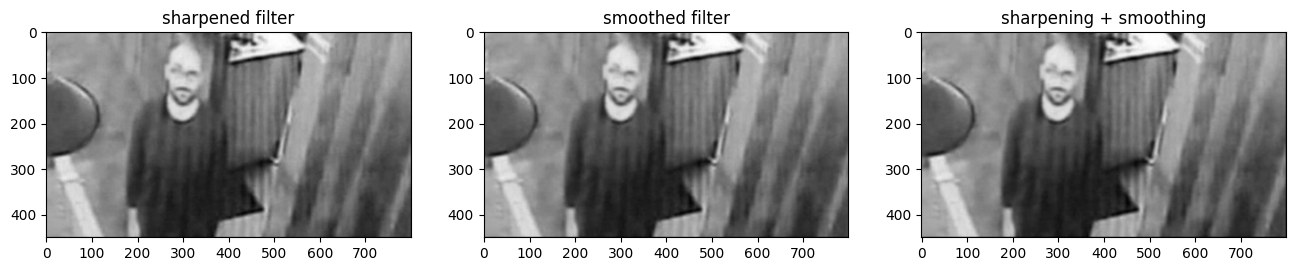

In [10]:
sharpening = convolution(backup, kernelSharpening)
smoothing = convolution(backup, kernelSmoothing)
smootsharp = convolution(smoothing+sharpening, kernelSharpening)

plt.figure(figsize=(16,8))
plt.subplot(2,3,1)
plt.title("sharpened filter")
plt.imshow(sharpening, cmap='gray')
plt.subplot(2,3,2)
plt.title("smoothed filter")
plt.imshow(smoothing, cmap='gray')
plt.subplot(2,3,3)
plt.imshow(smootsharp, cmap="gray")
plt.title("sharpening + smoothing")
plt.show()

Kode di atas menerapkan proses filtering pada citra backup menggunakan kernel sharpening dan smoothing. Hasil sharpening membuat detail dan tepi objek terlihat lebih tajam karena menonjolkan perubahan intensitas piksel, sedangkan smoothing menghaluskan citra dengan mengurangi noise sehingga gambar tampak lebih lembut namun detail sedikit berkurang. Pada bagian smootsharp, citra hasil smoothing dan sharpening digabung lalu diproses kembali dengan kernel sharpening sehingga menghasilkan citra yang lebih halus tetapi tetap memiliki detail tepi yang cukup jelas. Perbedaannya terletak pada efek yang dihasilkan, yaitu sharpening fokus mempertegas detail, smoothing fokus mengurangi noise, sementara kombinasi keduanya bertujuan menyeimbangkan kehalusan citra dan ketajaman objek.

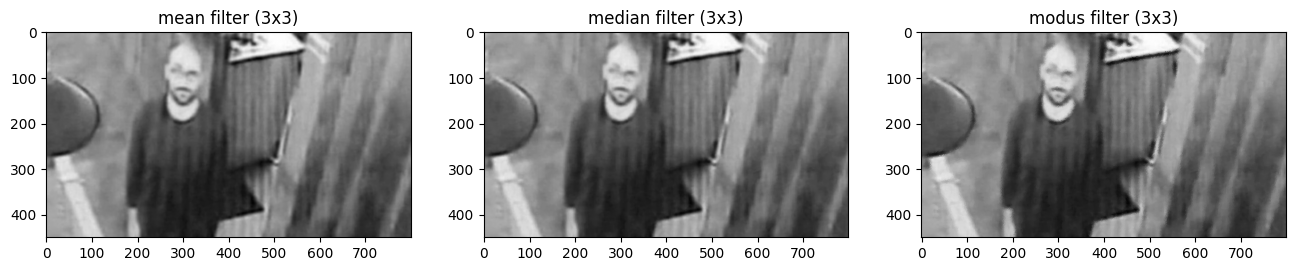

In [11]:
mean3x3 = filter(backup, 3, 'mean')
median3x3 = filter(backup, 3, 'median')
modus3x3 = filter(backup, 3, 'modus')

plt.figure(figsize=(16,8))
plt.subplot(2,3,1)
plt.title("mean filter (3x3)")
plt.imshow(mean3x3, cmap='gray')
plt.subplot(2,3,2)
plt.title("median filter (3x3)")
plt.imshow(median3x3, cmap='gray')
plt.subplot(2,3,3)
plt.title("modus filter (3x3)")
plt.imshow(modus3x3, cmap='gray')
plt.show()

Kode di atas menerapkan tiga jenis filter berukuran 3×3 pada citra backup, yaitu mean, median, dan modus filter untuk mengurangi noise dan memperbaiki kualitas citra. Mean filter bekerja dengan menghitung rata-rata nilai piksel di sekitar sehingga hasil citra menjadi lebih halus, namun detail dan tepi objek cenderung blur. Median filter mengganti nilai piksel dengan nilai tengah dari area kernel sehingga lebih efektif menghilangkan noise salt & pepper tanpa terlalu merusak tepi objek. Sementara itu, modus filter menggunakan nilai piksel yang paling sering muncul pada area kernel sehingga dapat mempertahankan pola dominan pada citra. Perbedaan hasil ketiganya terlihat pada tingkat kehalusan dan ketajaman gambar, di mana mean menghasilkan blur paling besar, median memberikan keseimbangan antara pengurangan noise dan detail, sedangkan modus cenderung mempertahankan bentuk atau pola piksel yang dominan.

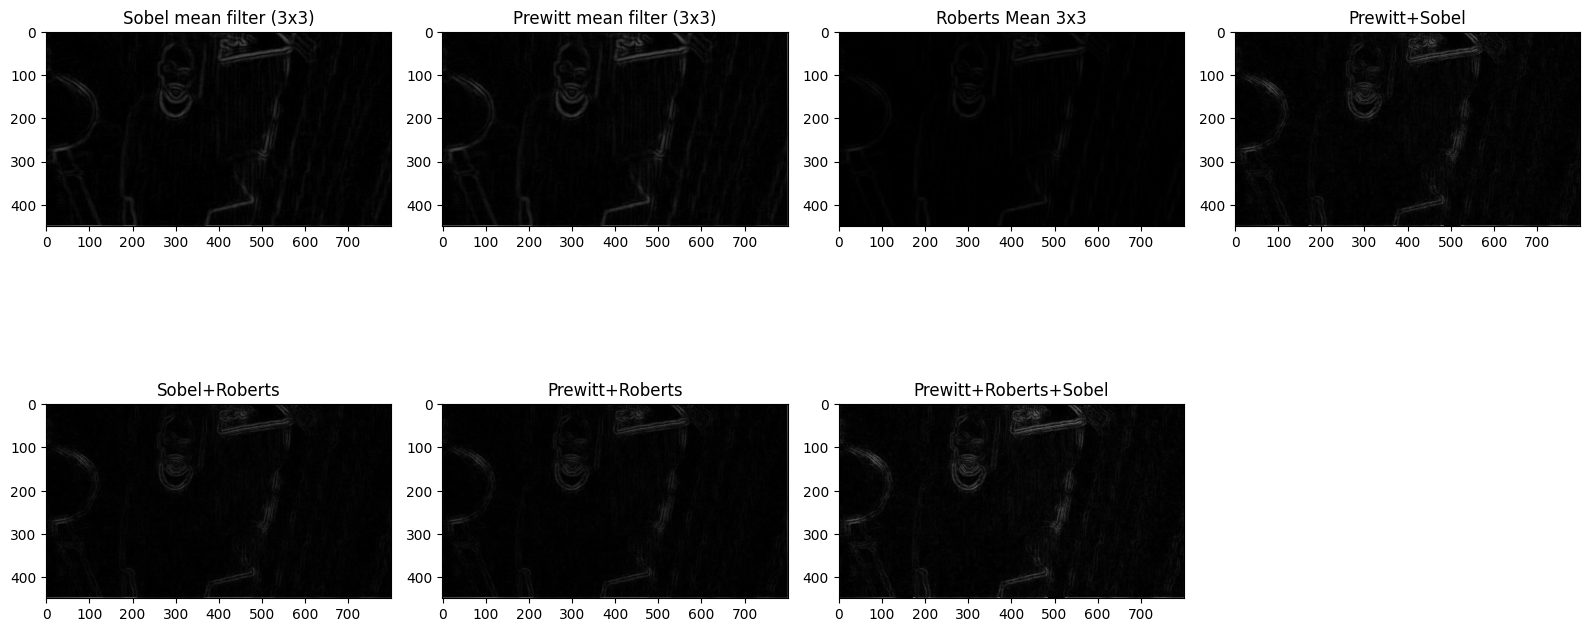

In [12]:
sobel_mean3 = edge(mean3x3, sobelX, sobelY)
prewitt_mean3 = edge(mean3x3, prewittX, prewittY)
roberts_mean3x3 = edge(mean3x3, robertsX, robertsY)
prewittSobel = edge(sobel_mean3+prewitt_mean3, sobelX, sobelY)
sobelRoberts = edge(sobel_mean3+roberts_mean3x3, sobelX, sobelY)
prewittRoberts = edge(prewitt_mean3+roberts_mean3x3, prewittX, prewittY)
prerobel = edge(prewitt_mean3+sobel_mean3+roberts_mean3x3, sobelX, sobelY)

plt.figure(figsize=(16,8))
plt.subplot(2,4,1)
plt.title("Sobel mean filter (3x3)")
plt.imshow(sobel_mean3, cmap='gray')

plt.subplot(2,4,2)
plt.title("Prewitt mean filter (3x3)")
plt.imshow(prewitt_mean3, cmap='gray')

plt.subplot(2,4,3)
plt.imshow(roberts_mean3x3, cmap='gray')
plt.title('Roberts Mean 3x3')

plt.subplot(2,4,4)
plt.imshow(prewittSobel, cmap='gray')
plt.title('Prewitt+Sobel')

plt.subplot(2,4,5)
plt.imshow(sobelRoberts, cmap='gray')
plt.title('Sobel+Roberts')

plt.subplot(2,4,6)
plt.imshow(prewittRoberts, cmap='gray')
plt.title('Prewitt+Roberts')

plt.subplot(2,4,7)
plt.imshow(prerobel, cmap='gray')
plt.title('Prewitt+Roberts+Sobel')

plt.tight_layout()
plt.show()

Operator Sobel digunakan untuk menghasilkan tepi yang lebih tegas dan detail karena memperhitungkan gradien dengan bobot lebih besar. Prewitt digunakan untuk mendeteksi tepi dengan hasil yang lebih halus dan sederhana, sedangkan Roberts lebih sensitif terhadap perubahan intensitas kecil sehingga mampu mendeteksi tepi tipis dan diagonal namun lebih mudah terkena noise. Kombinasi antar operator bertujuan menggabungkan kelebihan masing-masing metode, seperti Sobel+Prewitt yang menghasilkan tepi lebih jelas dan stabil, Sobel+Roberts yang menambah detail tepi halus, serta kombinasi ketiganya yang membuat tepi objek terlihat lebih lengkap dan kuat dibanding menggunakan satu operator saja.

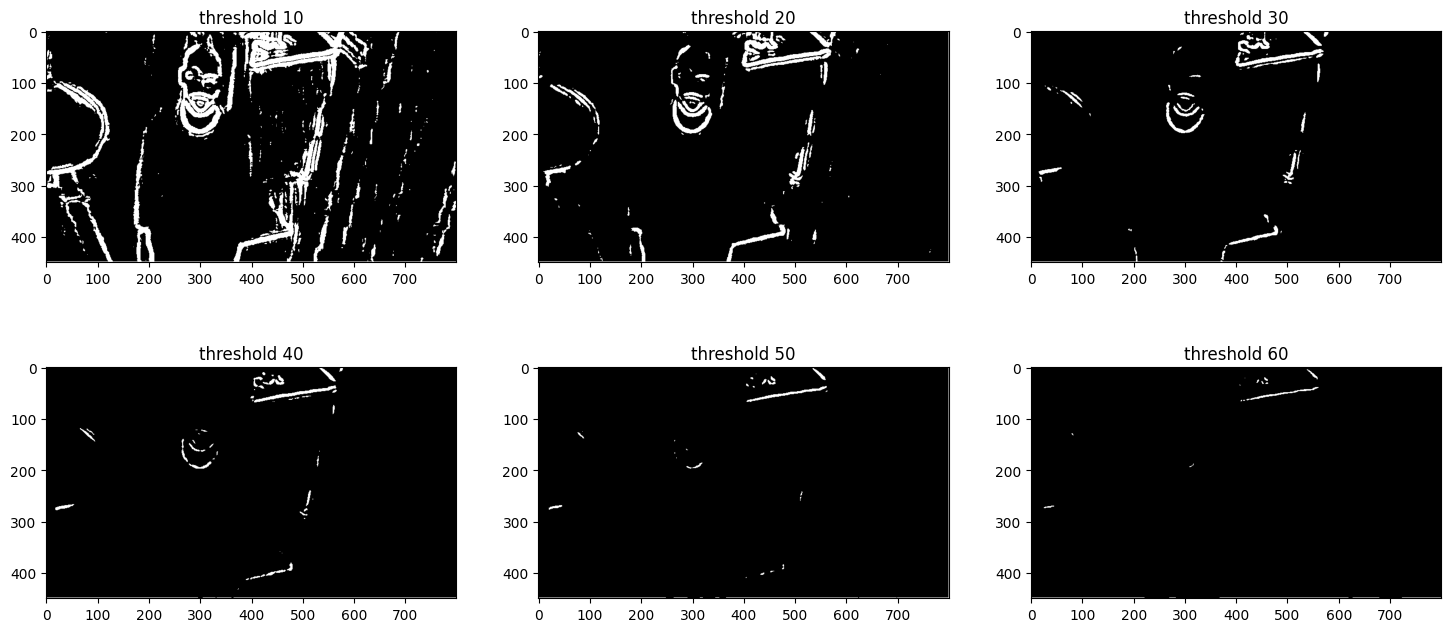

In [13]:
def threshold(img, thresh):
    height, width = img.shape
    canvas = np.zeros_like(img)

    for i in range(height):
        for j in range(width):

            if img[i, j] > thresh:
                canvas[i, j] = 255
            else:
                canvas[i, j] = 0

    return canvas.astype(np.uint8)


threshold10 = threshold(prewitt_mean3,10)
threshold20 = threshold(prewitt_mean3,20)
threshold30 = threshold(prewitt_mean3,30)
threshold40 = threshold(prewitt_mean3,40)
threshold50 = threshold(prewitt_mean3,50)
threshold60 = threshold(prewitt_mean3,60)

# TAMPILKAN SEMUA
plt.figure(figsize=(18,8))

plt.subplot(2,3,1)
plt.imshow(threshold10, cmap='gray')
plt.title('threshold 10')

plt.subplot(2,3,2)
plt.imshow(threshold20, cmap='gray')
plt.title('threshold 20')

plt.subplot(2,3,3)
plt.imshow(threshold30, cmap='gray')
plt.title('threshold 30')

plt.subplot(2,3,4)
plt.imshow(threshold40, cmap='gray')
plt.title('threshold 40')

plt.subplot(2,3,5)
plt.imshow(threshold50, cmap='gray')
plt.title('threshold 50')

plt.subplot(2,3,6)
plt.imshow(threshold60, cmap='gray')
plt.title('threshold 60')
plt.show()

penggunaan threshold berpengaruh terhadap jumlah detail tepi yg ditampilkan citra hasil segmentasi. threshold digunakan untuk menentukan batas apakah suatu piksel dianggap sebagai bagian tepi objek atau tidak. jika intensitas piksel lebih besar dari threshold maka piksel akan menjadi putih, sedangkan jika lebih kecil akan menjadi hitam. Perbedaan paling mencolok antara threshold rendah dan tinggi terletak pada sensitivitas deteksi tepi. Threshold rendah, seperti 10 atau 20, menghasilkan lebih banyak area putih sehingga detail tepi objek terlihat lebih lengkap, tetapi noise dan bagian yang tidak penting juga ikut muncul. Sebaliknya, threshold tinggi seperti 50 atau 60 hanya menampilkan tepi dengan intensitas kuat sehingga hasil terlihat lebih bersih dan rapi, namun beberapa detail objek dapat hilang karena dianggap bukan tepi penting.

Untuk kasus ini, nilai threshold yang paling baik adalah sekitar 30 atau 40 karena mampu memberikan keseimbangan antara detail objek dan pengurangan noise. Pada nilai tersebut, bentuk objek masih terlihat jelas tanpa terlalu banyak gangguan noise seperti pada threshold rendah, serta tidak terlalu kehilangan detail seperti pada threshold yang terlalu tinggi.

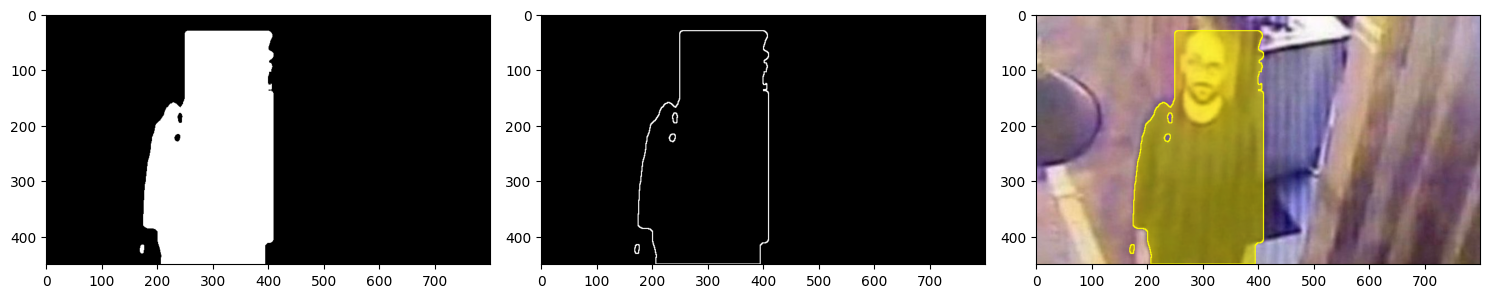

In [14]:
backup = cv2.imread('backup.jpg')
backup_rgb = cv2.cvtColor(backup, cv2.COLOR_BGR2RGB)
backup_gray = cv2.cvtColor(backup_rgb, cv2.COLOR_BGR2GRAY)

height, width = backup.shape[:2]

mask = np.zeros((height, width), dtype=np.uint8)
for i in range(height):
    for j in range(160, 410):
        mask[i, j] = 255

for i in range(250):
    for j in range(160, 210):
        r = int(backup_rgb[i, j, 0])
        g = int(backup_rgb[i, j, 1])
        b = int(backup_rgb[i, j, 2])
        if(r + g + b) // 3 < 70:
            mask[i, j] = 0

for i in range(height):
    for j in range(350, 410):
        r = int(backup_rgb[i, j, 0])
        g = int(backup_rgb[i, j, 1])
        b = int(backup_rgb[i, j, 2])
        rata = (r + g + b) // 3
        if rata > 130:
            mask[i, j] = 0

for i in range(10, 180):
    for j in range(230, 390):
        mask[i, j] = 255

for i in range(180, height):
    for j in range(185, 395):
        gray_val = int(backup_gray[i, j])
        if gray_val < 180:
            mask[i, j] = 255

for i in range(height):
    for j in range(160, 250):
        gray_val = int(backup_gray[i, j])
        if gray_val > 104:          
            mask[i, j] = 0

for i in range(0, 30):          
    for j in range(width):
        mask[i, j] = 0

mask = filter(mask, 9, 'median')
mask = threshold(mask, 127)

edge_line = edge(mask, sobelX, sobelY)
edge_line = threshold(edge_line, 30)

highlight = backup_rgb.copy()

# overlay highlight kuning transparan
for i in range(height):
    for j in range(width):

        if mask[i, j] == 255:

            r = int(highlight[i, j, 0])
            g = int(highlight[i, j, 1])
            b = int(highlight[i, j, 2])

            highlight[i, j, 0] = min(255, int(r * 0.6 + 255 * 0.4))
            highlight[i, j, 1] = min(255, int(g * 0.6 + 255 * 0.4))
            highlight[i, j, 2] = int(b * 0.3)

# outline kuning terang
for i in range(height):
    for j in range(width):

        if edge_line[i, j] == 255:
            highlight[i, j] = [255, 255, 0]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(mask, cmap='gray')

plt.subplot(1, 3, 2)
plt.imshow(edge_line, cmap='gray')

plt.subplot(1, 3, 3)
plt.imshow(highlight)

plt.tight_layout()
plt.show()

Kode di atas melakukan proses segmentasi dan highlight objek manusia pada citra CCTV backup.jpg. Pertama, citra diubah ke format RGB dan grayscale untuk mempermudah analisis warna serta intensitas piksel. Selanjutnya dibuat mask untuk menentukan area objek manusia berdasarkan rentang posisi dan kondisi nilai warna maupun grayscale sehingga background yang tidak diperlukan dapat dihilangkan. Setelah itu, mask diperhalus menggunakan median filter dan threshold agar area objek menjadi lebih bersih dan jelas. Proses deteksi tepi dilakukan menggunakan operator Sobel untuk menghasilkan outline objek. Pada tahap akhir, area objek yang terdeteksi diberikan overlay kuning transparan serta garis tepi kuning terang sehingga manusia pada citra CCTV terlihat lebih menonjol dan mudah dikenali dibanding background di sekitarnya.

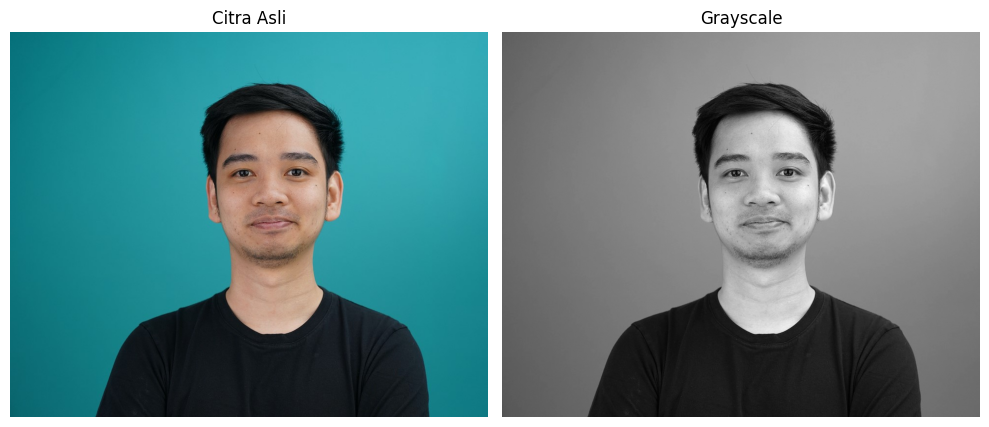

In [15]:
david = cv2.imread('david.jpg')
david_gray = cv2.cvtColor(david, cv2.COLOR_BGR2GRAY)
david_rgb = cv2.cvtColor(david, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(david_rgb)
plt.title('Citra Asli')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(david_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')
plt.tight_layout()
plt.show()

Kode di atas digunakan untuk membaca citra david.jpg, kemudian mengubahnya menjadi citra grayscale dan RGB. Konversi grayscale dilakukan untuk menyederhanakan informasi citra menjadi satu kanal intensitas sehingga mempermudah proses pengolahan citra seperti filtering dan deteksi tepi. Sementara itu, konversi ke RGB dilakukan agar warna citra tampil dengan benar saat ditampilkan menggunakan matplotlib. Hasil akhirnya menampilkan perbandingan antara citra asli berwarna dan citra grayscale sehingga perbedaan detail intensitas dan warna dapat diamati dengan jelas.

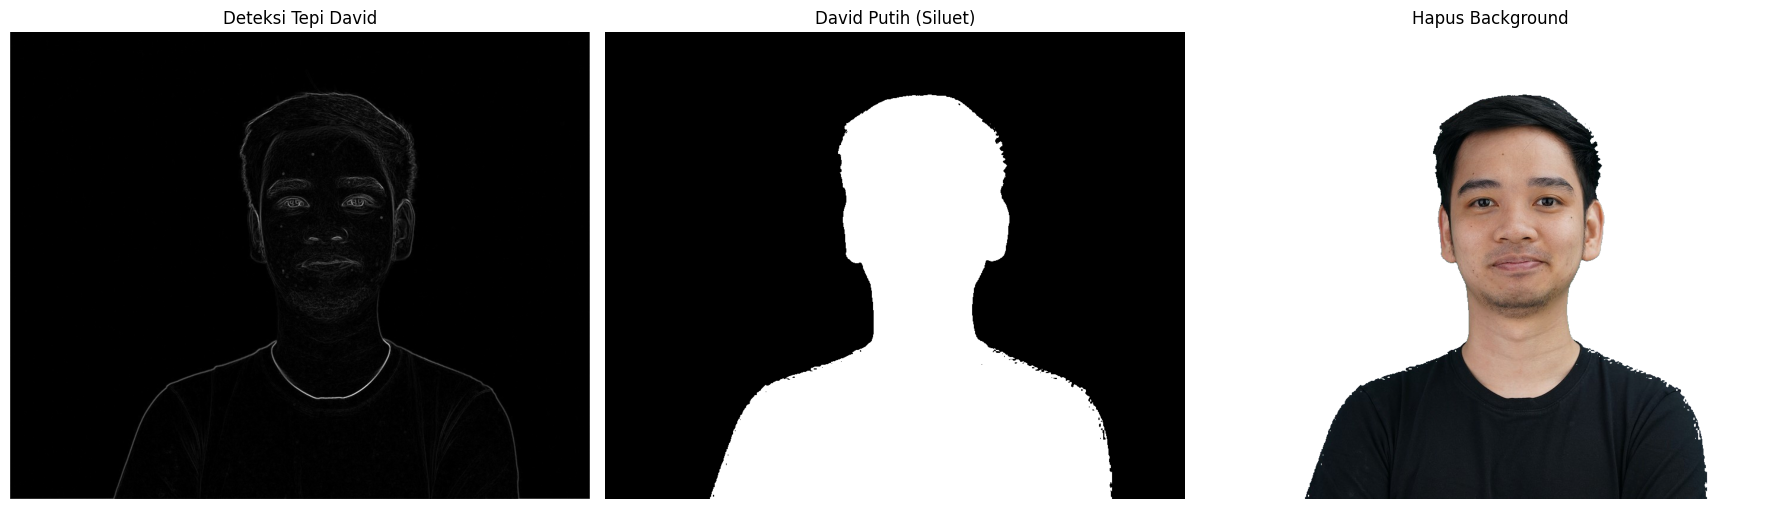

In [20]:
david_tepi = edge(david_gray, sobelX, sobelY)

height = david_rgb.shape[0]
width = david_rgb.shape[1]

david_nobg = np.zeros_like(david_rgb)
david_putih = np.zeros_like(david_rgb)

for i in range(height):
    for j in range(width):
        r = int(david_rgb[i, j, 0])
        g = int(david_rgb[i, j, 1])
        b = int(david_rgb[i, j, 2])
        
        if g > (r + 15) and b > (r + 15): 
            david_nobg[i, j] = [255, 255, 255]
        else:
            david_nobg[i, j] = [r, g, b]

        if not (g > (r + 15) and b > (r + 15)): 
            david_putih[i, j] = [255, 255, 255] 
        else:
            david_putih[i, j] = [0, 0, 0] 

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(david_tepi, cmap='gray')
plt.title('Deteksi Tepi David')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(david_putih)
plt.title('David Putih (Siluet)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(david_nobg)
plt.title('Hapus Background')
plt.axis('off')


plt.tight_layout()
plt.show()

Proses dimulai dengan citra david.jpg yang diubah menjadi grayscale untuk mempermudah deteksi tepi. Setelah itu dilakukan deteksi tepi menggunakan operator Sobel sehingga bagian tepi objek David terlihat lebih jelas berdasarkan perubahan intensitas piksel. Selanjutnya dilakukan proses penghilangan background dengan membandingkan nilai warna RGB pada setiap piksel. Jika nilai hijau (g) dan biru (b) lebih besar dari merah (r), maka piksel dianggap sebagai background dan diubah menjadi putih pada david_no_bg. Sebaliknya, bagian objek David dipertahankan dengan warna aslinya. Pada proses david_putih, objek David diubah menjadi siluet putih sementara background dibuat hitam. Hasil akhirnya menunjukkan perubahan dari citra awal menjadi citra tepi, lalu menjadi objek yang terpisah dari background sehingga objek utama lebih mudah dikenali dan dianalisis.